In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from HelperFunctions import *

- Import Dataset
- Convert Attribute Values

In [23]:
df = pd.read_csv('Quality of Service 5G.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Resource_Allocation'] = df['Resource_Allocation'].str.replace('%','').astype('int')
df['Latency'] = df['Latency'].str.replace('ms','').astype('float')
df['Signal_Strength'] = df['Signal_Strength'].str.replace(' dBm','').astype('int')

In [24]:
df['Required_Bandwidth'] = df['Required_Bandwidth'].map(mbps_to_kbps)
df['Allocated_Bandwidth'] = df['Allocated_Bandwidth'].map(mbps_to_kbps)
df['Required_Bandwidth'] = df['Required_Bandwidth'].str.replace(' Kbps','').astype('float')
df['Allocated_Bandwidth'] = df['Allocated_Bandwidth'].str.replace(' Kbps','').astype('float')
df

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,2023-09-03 10:00:00,User_1,Video_Call,-75,30.0,10000.0,15000.0,70
1,2023-09-03 10:00:00,User_2,Voice_Call,-80,20.0,100.0,120.0,80
2,2023-09-03 10:00:00,User_3,Streaming,-85,40.0,5000.0,6000.0,75
3,2023-09-03 10:00:00,User_4,Emergency_Service,-70,10.0,1000.0,1500.0,90
4,2023-09-03 10:00:00,User_5,Online_Gaming,-78,25.0,2000.0,3000.0,85
...,...,...,...,...,...,...,...,...
395,2023-09-03 10:06:00,User_396,Streaming,-110,61.0,1300.0,1800.0,85
396,2023-09-03 10:06:00,User_397,Video_Call,-40,53.0,14500.0,15800.0,75
397,2023-09-03 10:06:00,User_398,Video_Streaming,-113,58.0,1000.0,1400.0,70
398,2023-09-03 10:06:00,User_399,Emergency_Service,-40,5.0,400.0,400.0,70


- Heatmap for numeric columns

Positive values in heatmap: Positive correlation (increase var1 => increase var2)

Negative values in heatmap: Negative correlation (increase var1 => decrease var2)

Zero values in heatmap: No correlation

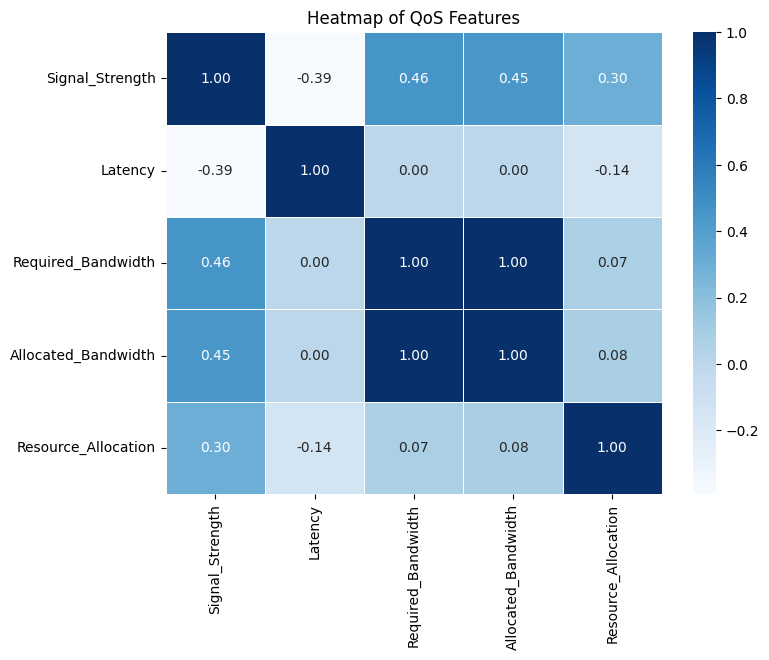

In [25]:
numeric_vars = ["Signal_Strength", "Latency", "Required_Bandwidth", "Allocated_Bandwidth", "Resource_Allocation"]

df_numeric = df[numeric_vars]
correlation_matrix = df_numeric.corr()

plot_heatmap(correlation_matrix)

- Z-score for numeric columns

Scaler returns numpy array, we convert it back to data frame

In [26]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

df_scaled

,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,0.265777,-0.181316,1.725130,2.580707,-0.525300
1,0.023942,-0.655346,-0.762862,-0.759195,0.589396
2,-0.217894,0.292713,0.468569,0.560605,0.032048
3,0.507612,-1.129376,-0.536680,-0.449446,1.704091
4,0.120676,-0.418331,-0.285368,-0.112762,1.146743
...,...,...,...,...,...
395,-1.427070,1.288176,-0.461287,-0.382109,1.146743
396,1.958624,0.908952,2.856035,2.760271,0.032048
397,-1.572171,1.145967,-0.536680,-0.471891,-0.525300
398,1.958624,-1.366391,-0.687468,-0.696347,-0.525300


- Elbow Method For K-means Algorithm

The optimal number of clusters Elbow Method: 6


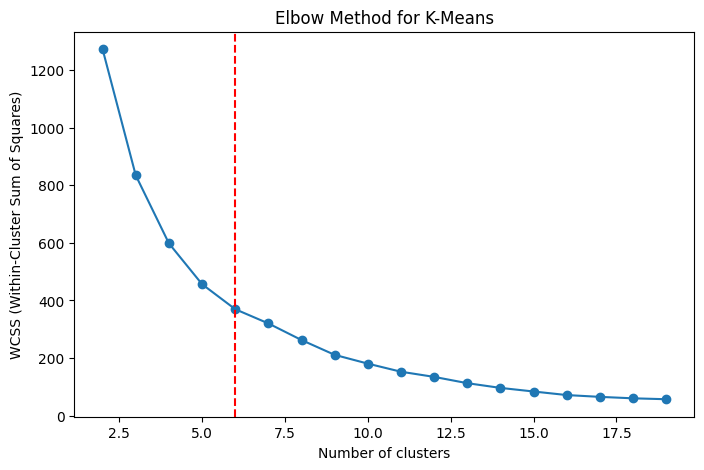

Optimal number of clusters C-Index: 17
Optimal number of clusters Silhouette Score: 16


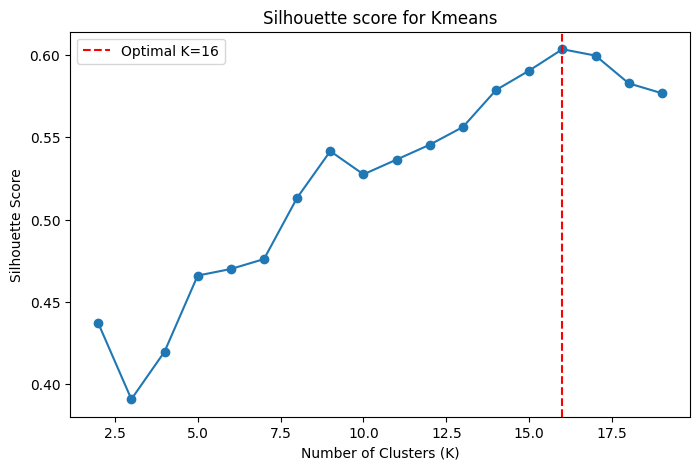

In [27]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

# K 2 - 366: 400 rows(/datapoints) in df_scaled - 34 duplicate rows
wcss = []  # Within-cluster sum of squares
c_index_kmeans = [] #C-index of each cluster iteration
silhouette_scores = []
data = df_scaled.values  # Convert to numpy array
K_range = range(2, min(20, len(df_scaled)))

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # kmeans.fit(df_scaled)
    labels_kmeans = kmeans.fit_predict(data)
    wcss.append(kmeans.inertia_)
    c_index_kmeans.append(compute_c_index(data, labels_kmeans))
    silhouette_scores.append(silhouette_score(df_scaled, labels_kmeans))

'''
Elbow Point
'''
# Use Knee Locator to find Elbow Point
kneedle = KneeLocator(list(K_range), wcss, curve="convex", direction="decreasing")
elbow_k = kneedle.elbow
print(f"The optimal number of clusters Elbow Method: {elbow_k}")
plot_elbow_kmeans(elbow_k,K_range,wcss)

'''
C-index
'''
cindex_k = list(K_range)[np.argmin(c_index_kmeans)]
print(f"Optimal number of clusters C-Index: {cindex_k}")

'''
Highest Silhouette Score
'''
silhouette_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters Silhouette Score: {silhouette_k}")
plot_silhouette_scores(silhouette_k,K_range,silhouette_scores,"Silhouette score for Kmeans")


- Compare optimal results

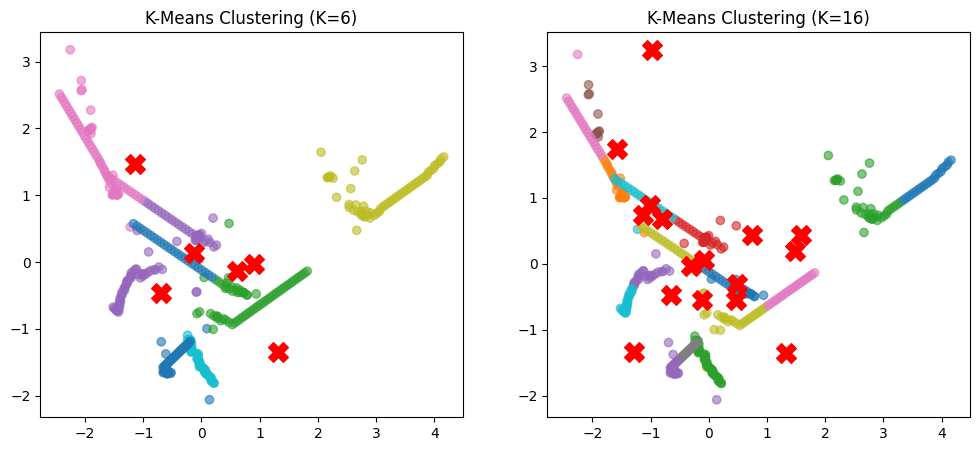

In [28]:
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_6 = kmeans_6.fit_predict(df_scaled)

kmeans_16 = KMeans(n_clusters=16, random_state=42, n_init=10)
labels_16 = kmeans_16.fit_predict(df_scaled)

from sklearn.decomposition import PCA

# Reduce data to 2D
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Scatter plot for K=6
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_6, cmap='tab10', alpha=0.6)
plt.scatter(kmeans_6.cluster_centers_[:, 0], kmeans_6.cluster_centers_[:, 1], marker='X', s=200, c='red')
plt.title("K-Means Clustering (K=6)")

# Scatter plot for K=16
plt.subplot(1, 2, 2)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_16, cmap='tab10', alpha=0.6)
plt.scatter(kmeans_16.cluster_centers_[:, 0], kmeans_16.cluster_centers_[:, 1], marker='X', s=200, c='red')
plt.title("K-Means Clustering (K=16)")

plt.show()

- Run K-means Algorithm for optimal number of clusters based on PCA results

In [29]:
# Optimal number of clusters for K-means based on PCA is 
kmeans = KMeans(n_clusters=16, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

- Ward Linkage Method

Ward linkage is a method used in hierarchical clustering to determine the distance between two clusters before merging them.
The goal of Ward linkage is to minimize the increase in variance within the newly formed cluster when two clusters are combined.

https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html

- Dendogram for agglomerative with Ward Method

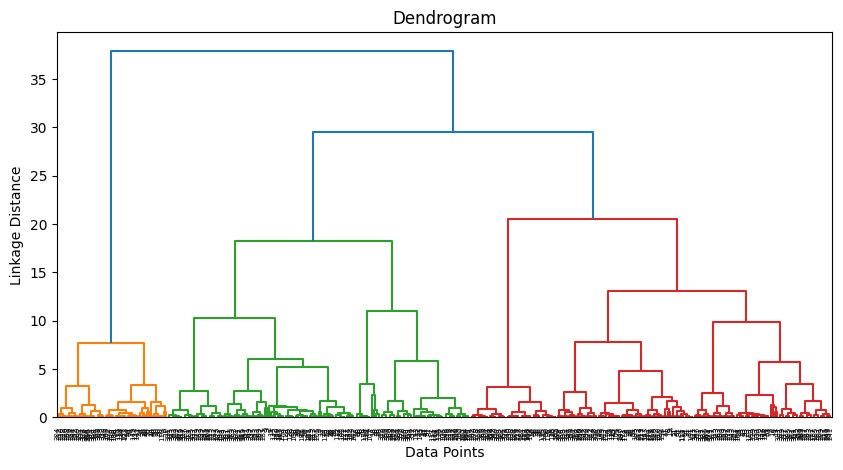

In [30]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Compute the Ward linkage matrix
linkage_matrix = sch.linkage(df_scaled, method='ward')

plot_dendogram(linkage_matrix)

- Find Elbow Optimal K 

The optimal number of clusters is: 29


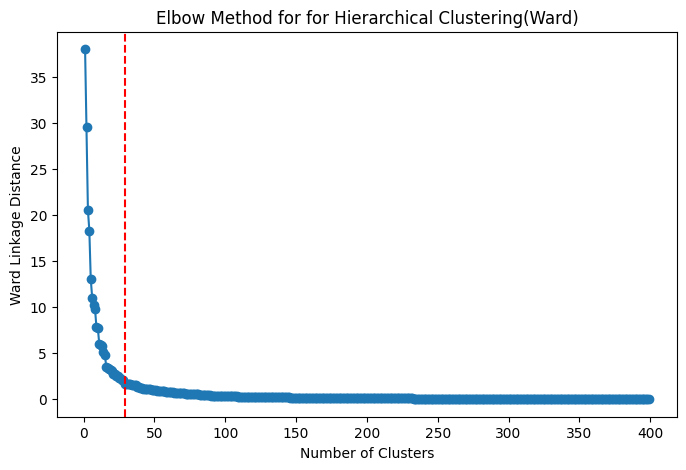

Optimal number of clusters from Silhouette Score: 18


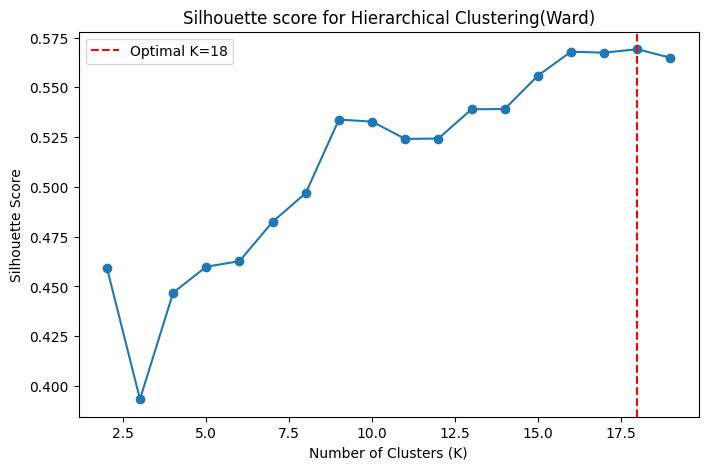

In [31]:
# Extract the distances at which clusters merge
distances = linkage_matrix[:, 2]  # Column 2 contains the distances
num_clusters = range(len(distances), 0, -1)

# Use KneeLocator to find the optimal number of clusters
hier_kneedle = KneeLocator(num_clusters, distances, curve="convex", direction="decreasing")

hier_elbow_k = hier_kneedle.elbow
print(f"The optimal number of clusters is: {hier_elbow_k}")

plot_elbow_ward(hier_elbow_k, num_clusters, distances)

hier_silhouette_scores = []

for k in K_range:
    cluster_labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(df_scaled)
    score = silhouette_score(df_scaled, cluster_labels)
    hier_silhouette_scores.append(score)
    
    # Find the best K (highest silhouette score)
optimal_silhouette_k = K_range[np.argmax(hier_silhouette_scores)]
print(f"Optimal number of clusters from Silhouette Score: {optimal_silhouette_k}")
plot_silhouette_scores(optimal_silhouette_k,K_range,hier_silhouette_scores,"Silhouette score for Hierarchical Clustering(Ward)")

- Optimal K Ward

Text(0.5, 1.0, 'Hierarchical Clustering (K=29)')

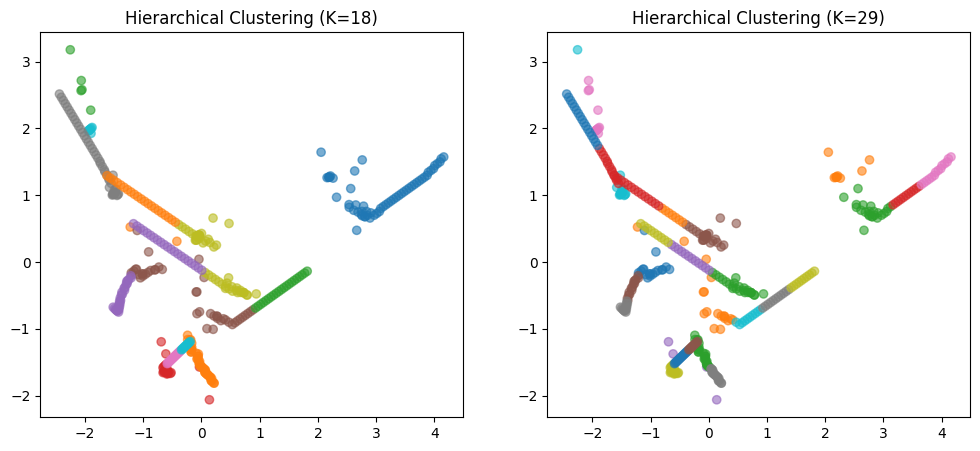

In [32]:
hierarchical_18 = AgglomerativeClustering(n_clusters=18, linkage='ward')
hierarchical_cluster_labels_18 = hierarchical_18.fit_predict(df_scaled)

hierarchical_29 = AgglomerativeClustering(n_clusters=29, linkage='ward')
hierarchical_cluster_labels_29 = hierarchical_29.fit_predict(df_scaled)

# Scatter plot for K=18
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=hierarchical_cluster_labels_18, cmap='tab10', alpha=0.6)
plt.title("Hierarchical Clustering (K=18)")

# Scatter plot for K=29
plt.subplot(1, 2, 2)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=hierarchical_cluster_labels_29, cmap='tab10', alpha=0.6)
plt.title("Hierarchical Clustering (K=29)")



- Apply Hierarchical Agglomerative Clustering Algorithm with Ward Linkage distance metric

For k = 29 we see too many clusters some overlapping 

In [33]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=18, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(df_scaled)

- Comrare K-means and Hierarchical


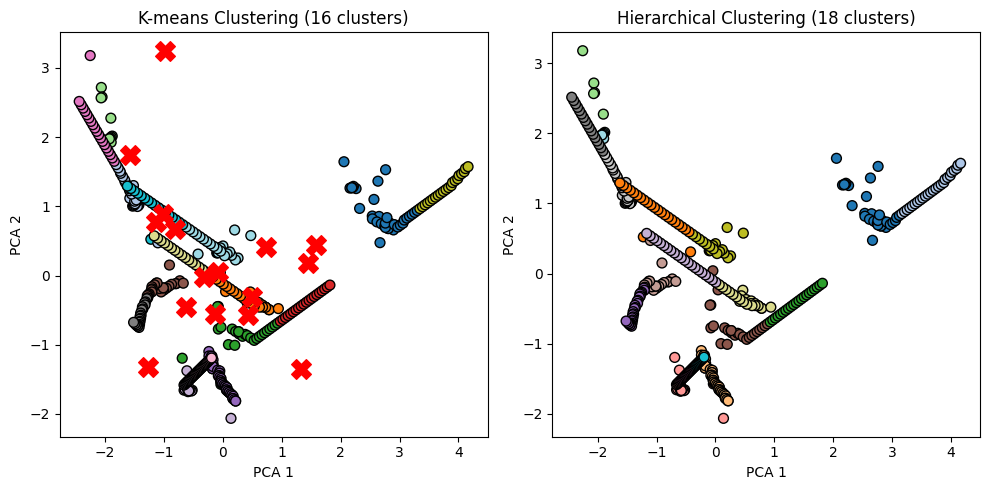

In [44]:
from sklearn.decomposition import PCA

# Reduce to 2D using PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Plot K-means clusters
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels, cmap='tab20', edgecolor='k', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200, c='red')
plt.title("K-means Clustering (16 clusters)")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

# Plot Hierarchical clusters
plt.subplot(1, 2, 2)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=hierarchical_labels, cmap='tab20', edgecolor='k', s=50)
plt.title("Hierarchical Clustering (18 clusters)")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.tight_layout()
plt.show()


- Pair Plot

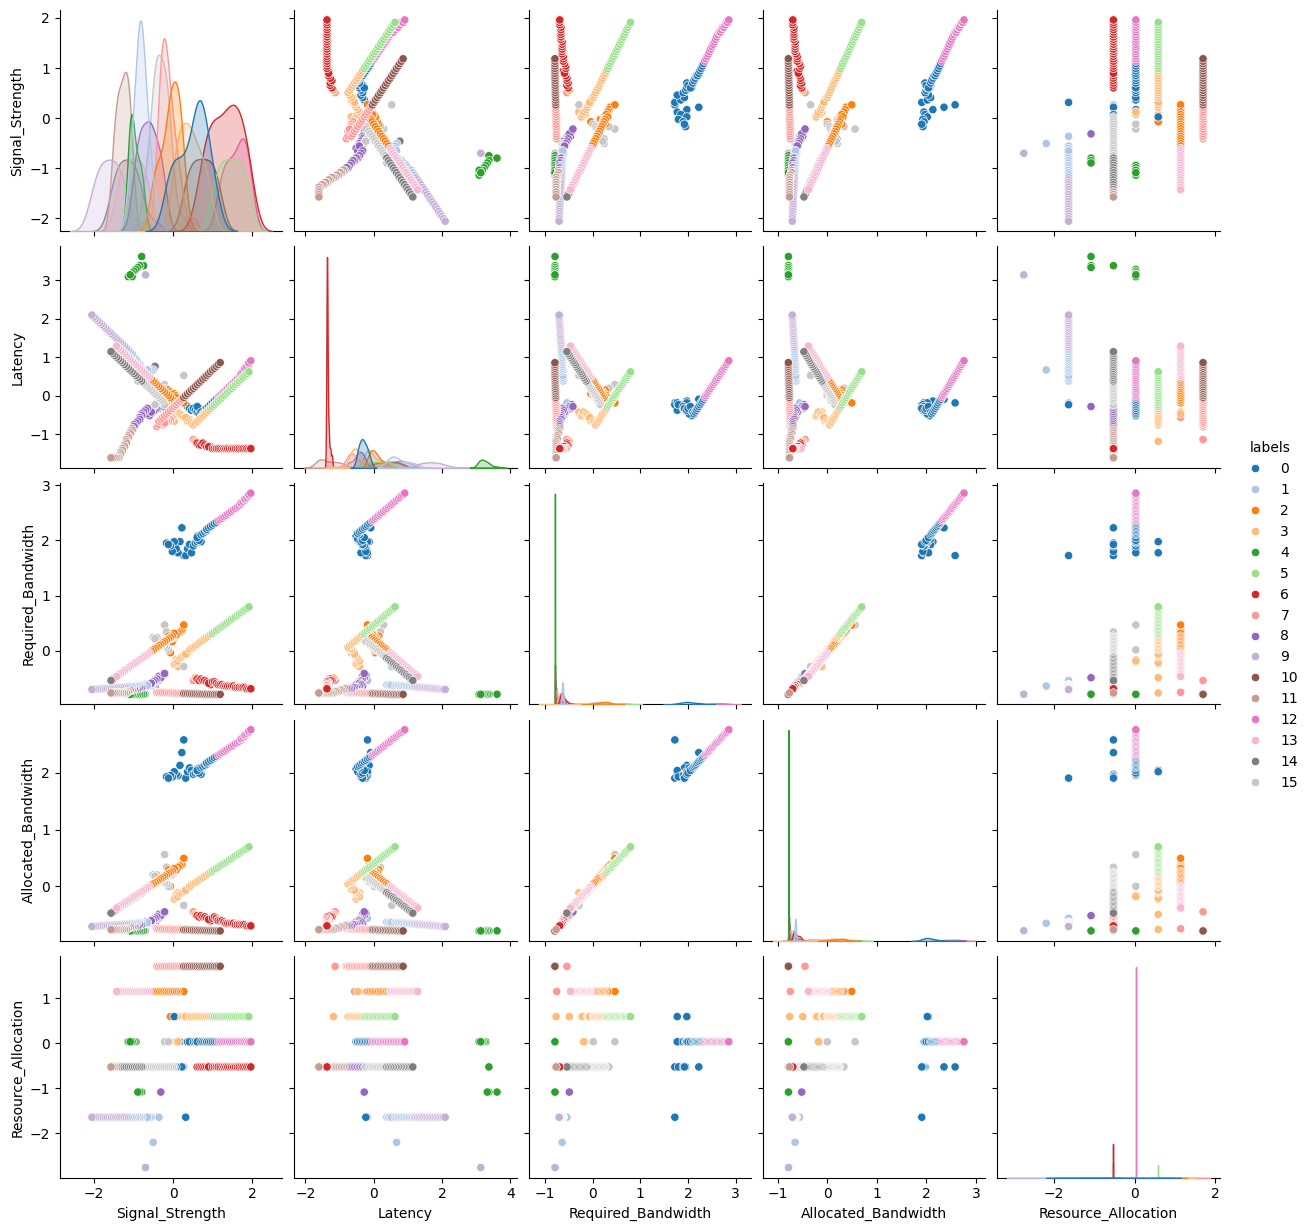

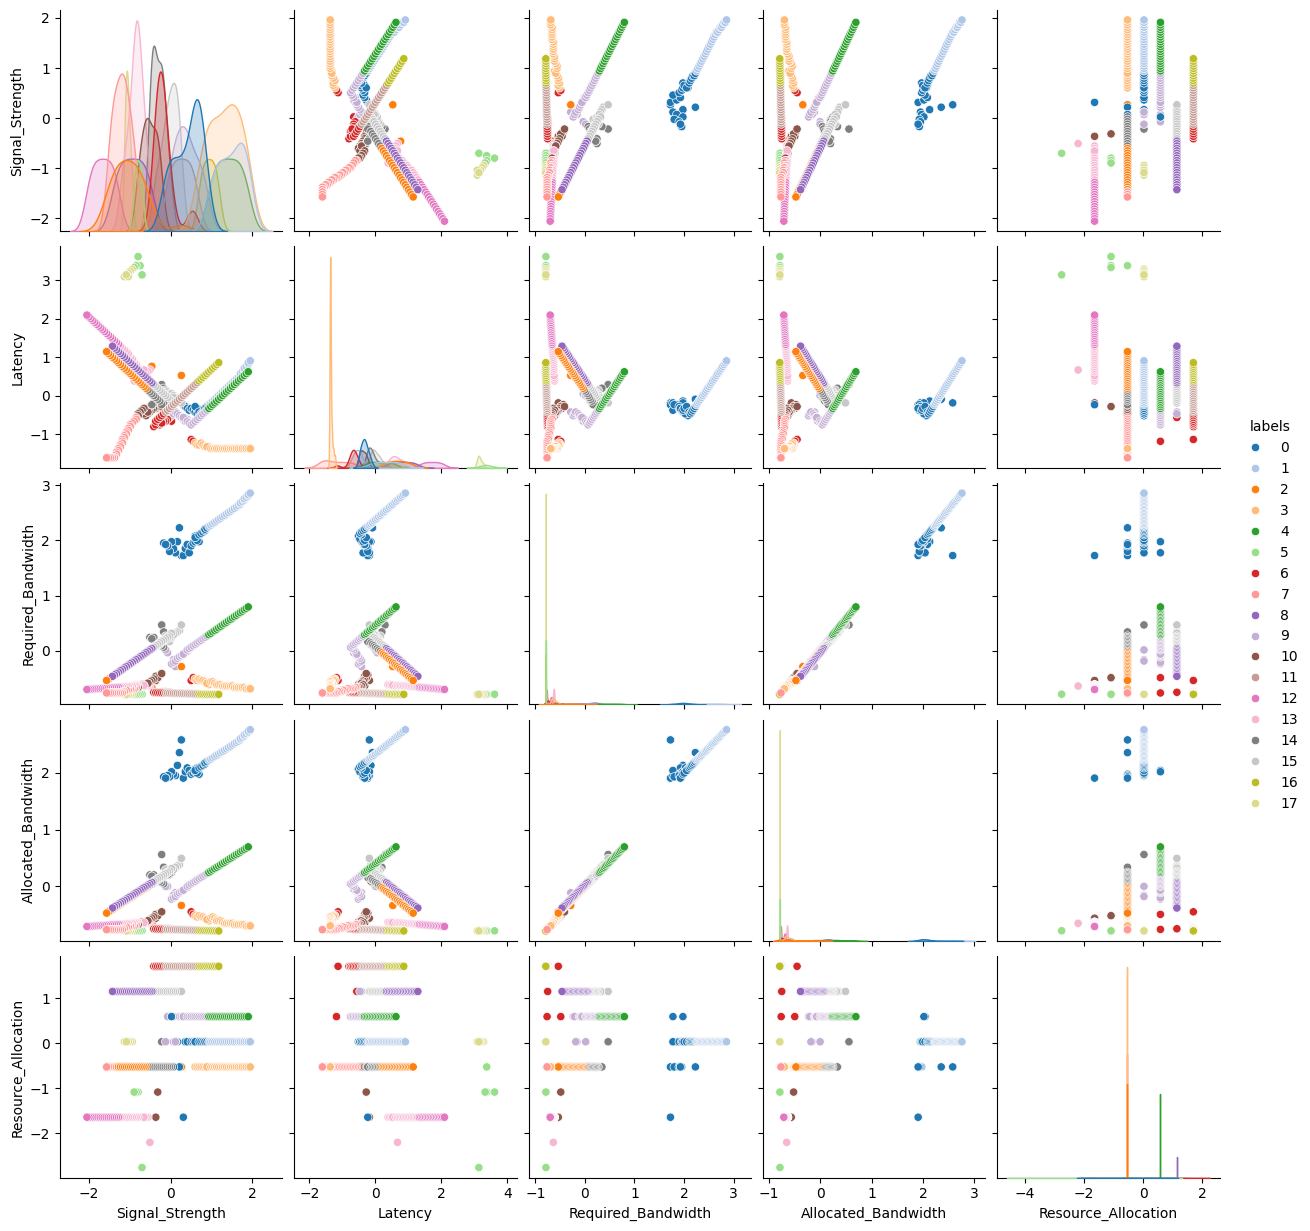

In [35]:
# Create a DataFrame with cluster labels
df_for_plot = pd.DataFrame(df_scaled)
df_for_plot['labels'] = kmeans_labels

# Plot pair plot with custom palette
sns.pairplot(df_for_plot, hue='labels', palette='tab20')
plt.show()

df_for_plot['labels'] = hierarchical_labels
sns.pairplot(df_for_plot, hue='labels', palette='tab20')
plt.show()


In [36]:
# Number of data points in each cluster
kmeans_counts = np.bincount(kmeans_labels)
hierarchical_counts = np.bincount(hierarchical_labels)

print(f"K-Means Cluster Sizes: {kmeans_counts}")
print(f"Hierarchical Cluster Sizes: {hierarchical_counts}")


K-Means Cluster Sizes: [36 28 28 27 12 20 45 28 24 20 20 23 21 18 18 32]
Hierarchical Cluster Sizes: [32 25 23 45 21  5 22 29 21 26 19 17 17 29 26 24 11  8]


- SOM

In [37]:
from minisom import MiniSom

N = df_scaled.shape[0]
grid_size = int(5 * np.sqrt(N))
som_shape = (grid_size, grid_size)
som = MiniSom(grid_size, grid_size, data.shape[1], sigma=.5, learning_rate=.5, sigma_decay_function='inverse_decay_to_one',   decay_function ='inverse_decay_to_zero',neighborhood_function='gaussian',activation_distance='euclidean' ,random_seed=10)

som.train_batch(data, N, verbose=False)
 # som_cluster_labels ??
winner_coordinates = np.array([som.winner(x) for x in data]).T
# Convert 2D coordinates into 1D indices.
cluster_index = np.ravel_multi_index(winner_coordinates, som_shape)


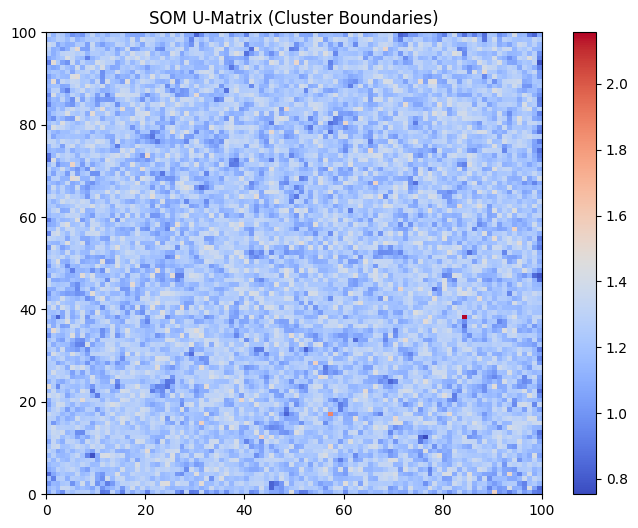

In [38]:
from pylab import plot, colorbar, pcolor

# Compute distances between neurons
u_matrix = np.zeros((som_shape[0], som_shape[1]))

for i in range(som_shape[0]):
    for j in range(som_shape[1]):
        neighbors = som.get_weights()[max(0, i-1):i+2, max(0, j-1):j+2]
        u_matrix[i, j] = np.mean(np.linalg.norm(neighbors - som.get_weights()[i, j], axis=-1))

# Plot U-Matrix
plt.figure(figsize=(8, 6))
pcolor(u_matrix, cmap='coolwarm')  # Choose color map
colorbar()
plt.title('SOM U-Matrix (Cluster Boundaries)')
plt.show()


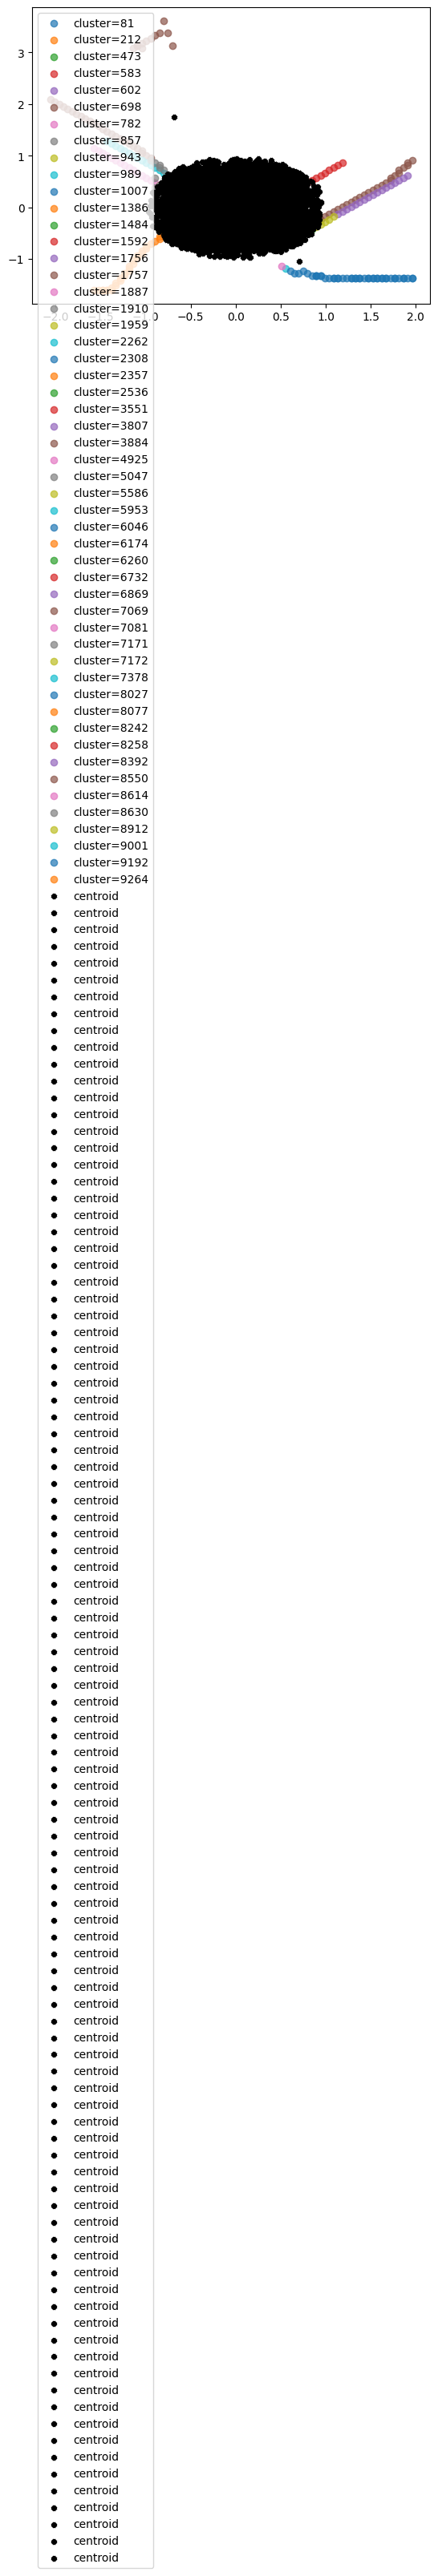

In [45]:
%matplotlib inline

# plotting the clusters using the first 2 dimentions of the data
for c in np.unique(cluster_index):
    plt.scatter(data[cluster_index == c, 0],
                data[cluster_index == c, 1], label='cluster='+str(c), alpha=.7)

# plotting centroids
for centroid in som.get_weights():
    plt.scatter(centroid[:, 0], centroid[:, 1], marker='x', 
                s=5, linewidths=5, color='k', label='centroid')
plt.legend();